In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/iris/Iris.csv
/kaggle/input/datasets/uciml/iris/database.sqlite


In [2]:
import os

# Find the uploaded dataset

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/uciml/iris/Iris.csv
/kaggle/input/datasets/uciml/iris/database.sqlite


In [3]:
import pandas as pd

# Load Iris dataset
df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!
Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [4]:
# Inspect target classes

print("Target column value counts:")
print(df["Species"].value_counts())

print("\nUnique species:")
print(df["Species"].unique())

Target column value counts:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Unique species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


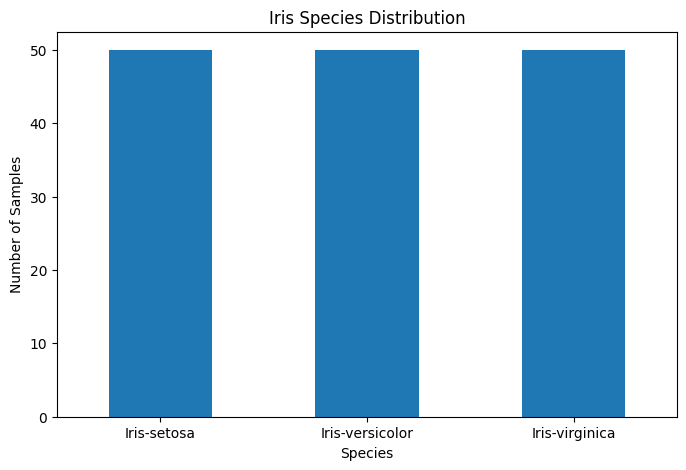

In [5]:
import matplotlib.pyplot as plt

# Visualize Iris classes

plt.figure(figsize=(8, 5))

df["Species"].value_counts().plot(kind="bar")

plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.title("Iris Species Distribution")

plt.xticks(rotation=0)

plt.show()

In [6]:
# Select features and target

X = df.drop(columns=["Id", "Species"])
y = df["Species"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (150, 4)
Target shape: (150,)

Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [7]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [8]:
from sklearn.preprocessing import StandardScaler

# Normalize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features normalized successfully!")

print("\nFirst 5 normalized training rows:")
print(X_train_scaled[:5])

Features normalized successfully!

First 5 normalized training rows:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train KNN classifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")
print("K value:", 5)

KNN model trained successfully!
K value: 5


In [10]:
# Make predictions using KNN

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.9333333333333333


In [11]:
# Test different values of K

k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train_scaled, y_train)
    
    predictions = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, predictions)
    
    k_accuracies.append(accuracy)

k_results = pd.DataFrame({
    "K": list(k_values),
    "Accuracy": k_accuracies
})

display(k_results)

,K,Accuracy
0,1,0.966667
1,2,0.933333
2,3,0.933333
3,4,0.933333
4,5,0.933333
5,6,0.933333
6,7,0.966667
7,8,0.933333
8,9,0.966667
9,10,0.966667


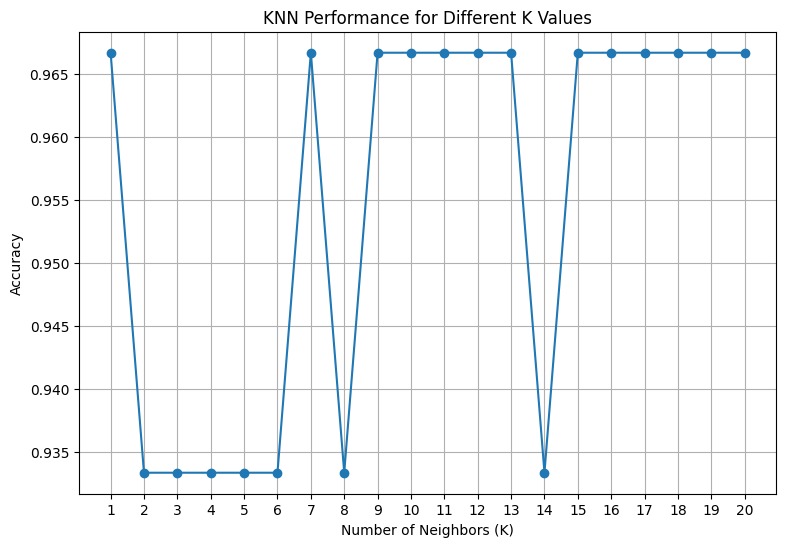

In [12]:
# Visualize K value performance

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    k_accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Performance for Different K Values")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [13]:
# Find the best K value

import numpy as np

best_index = np.argmax(k_accuracies)

best_k = list(k_values)[best_index]
best_accuracy = k_accuracies[best_index]

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 1
Best Accuracy: 0.9666666666666667


In [14]:
# Train final KNN model using the best K

final_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

final_knn.fit(
    X_train_scaled,
    y_train
)

final_pred = final_knn.predict(
    X_test_scaled
)

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

print("Final KNN Model")
print("----------------")
print("Best K:", best_k)
print("Test Accuracy:", final_accuracy)

Final KNN Model
----------------
Best K: 1
Test Accuracy: 0.9666666666666667


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


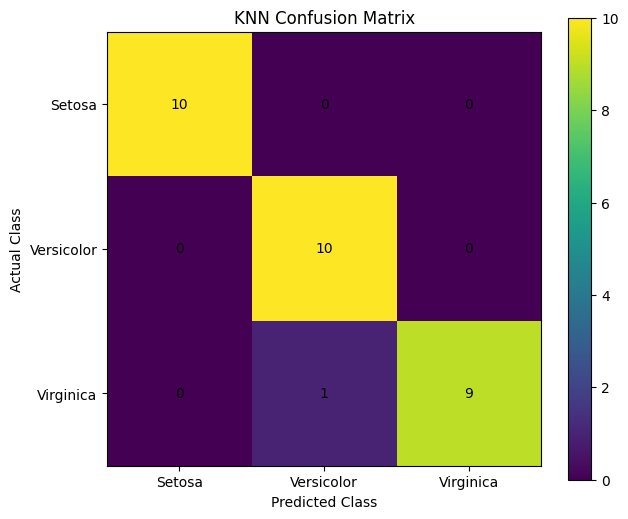

In [15]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    final_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

plt.yticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [16]:
from sklearn.metrics import classification_report

# Classification Report

print("KNN Classification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        final_pred
    )
)

KNN Classification Report
-------------------------
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [17]:
# Select two features for decision boundary visualization

X_2d = df[
    ["PetalLengthCm", "PetalWidthCm"]
]

y_2d = df["Species"]

print("2D features selected:")
print(X_2d.columns.tolist())

2D features selected:
['PetalLengthCm', 'PetalWidthCm']


In [18]:
# Split and scale the 2D data

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.20,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

print("2D data prepared successfully!")
print("Training data:", X2_train_scaled.shape)
print("Testing data:", X2_test_scaled.shape)

2D data prepared successfully!
Training data: (120, 2)
Testing data: (30, 2)


In [19]:
# Train KNN using the two selected features

knn_2d = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_2d.fit(
    X2_train_scaled,
    y2_train
)

print("2D KNN model trained successfully!")

2D KNN model trained successfully!


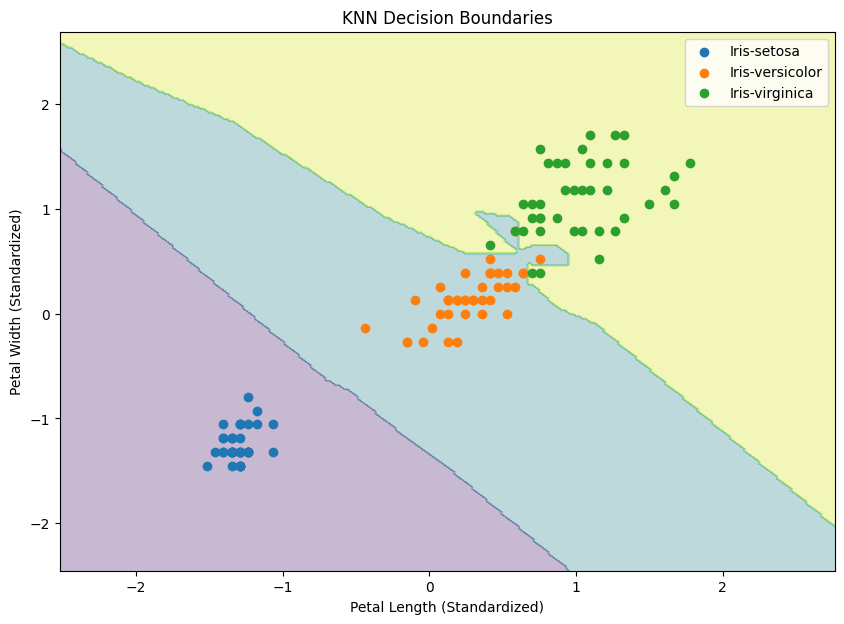

In [20]:
# Visualize KNN decision boundaries

import numpy as np

x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = knn_2d.predict(grid_points)

# Convert class labels to numeric values
class_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

Z_numeric = np.array([
    class_mapping[label]
    for label in Z
])

Z_numeric = Z_numeric.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.3
)

for species, label in class_mapping.items():
    
    mask = y2_train == species
    
    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=species
    )

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("KNN Decision Boundaries")
plt.legend()

plt.show()

In [21]:
# Final Task 6 results

print("=" * 50)
print("FINAL TASK 6 RESULTS")
print("=" * 50)

print(f"Best K: {best_k}")
print(f"Final KNN Accuracy: {final_accuracy:.4f}")

print("\nK Values Tested:")
print("1 to 20")

print("\nDataset:")
print("Iris Dataset")

print("\nNumber of Features:")
print(X.shape[1])

print("\nTraining Samples:")
print(X_train.shape[0])

print("\nTesting Samples:")
print(X_test.shape[0])

print("=" * 50)

FINAL TASK 6 RESULTS
Best K: 1
Final KNN Accuracy: 0.9667

K Values Tested:
1 to 20

Dataset:
Iris Dataset

Number of Features:
4

Training Samples:
120

Testing Samples:
30


## Conclusion

In this task, K-Nearest Neighbors (KNN) classification was implemented using the Iris dataset.

The dataset was divided into training and testing sets using an 80:20 split. The numerical features were standardized using StandardScaler because KNN is a distance-based algorithm and feature scaling is important for reliable distance calculations.

A KNN classifier was trained and different values of K from 1 to 20 were tested. The accuracy of each K value was compared to identify the best-performing value of K.

The final KNN model was evaluated using test accuracy, a confusion matrix, and a classification report.

Decision boundaries were also visualized using Petal Length and Petal Width, allowing the classification regions of the KNN model to be observed in two dimensions.

Overall, this task demonstrated how KNN can be used for classification, how feature normalization affects distance-based models, how K can be tuned, and how decision boundaries can be visualized.